# Resultado final — as quatro variantes de limpeza

Quatro varreduras de **10.368 configurações cada** no ClearML, sobre os mesmos 16 meses.
Só a operabilidade muda entre elas:

| # | variante | filtro de temperatura (T5 ≥ 500 °C) | silêncio de 24 h pós-partida |
|---|---|---|---|
| 1 | referência (produção hoje) | — | — |
| 2 | silêncio 24 h | — | ✓ |
| 3 | filtro T5 | ✓ | — |
| 4 | T5 + silêncio | ✓ | ✓ |

O critério é o de sempre: só entra na disputa quem respeita o **teto de 1 falso positivo por
mês**; entre esses, mais falhas antecipadas, depois menos horas por mês em alarme falso.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src")); sys.path.insert(0, str(RAIZ / "scripts"))
warnings.filterwarnings("ignore")

from cabiunas_pdm import viz
from cabiunas_pdm.replay import DetectionReplay, CachedBundle, load_automl
automl = load_automl(); viz.usar_estilo(); pd.set_option("display.width", 220)

TETO_FP = 1.0
AUTOML = RAIZ / "reports/automl"
VARIANTES = {"1. referência":    dict(arquivo="res_baseline.parquet",     gate="off",    silencio="0h"),
             "2. silêncio 24 h": dict(arquivo="res_silencio_v2.parquet",  gate="off",    silencio="24h"),
             "3. filtro T5":     dict(arquivo="res_t5gate.parquet",       gate="stable", silencio="0h"),
             "4. T5 + silêncio": dict(arquivo="res_t5_silencio.parquet",  gate="stable", silencio="24h")}
D = {n: pd.read_parquet(AUTOML / v["arquivo"]) for n, v in VARIANTES.items()}
print({n: len(d) for n, d in D.items()})

{'1. referência': 10368, '2. silêncio 24 h': 10368, '3. filtro T5': 10368, '4. T5 + silêncio': 10368}


## 1. O melhor ponto de cada variante

Aqui cada variante aparece com a configuração que ela consegue de melhor — e o modelo
vencedor **muda entre elas**, o que já é informação.

In [2]:
linhas = []
for nome, d in D.items():
    ok = d[d.fp_por_mes <= TETO_FP]
    if ok.empty:
        linhas.append(dict(variante=nome, eventos="—", situacao="nenhuma config no teto")); continue
    b = ok.sort_values(["eventos_detectados", "fp_horas_por_mes"], ascending=[False, True]).iloc[0]
    linhas.append(dict(
        variante=nome, eventos=f"{int(b.eventos_detectados)}/8", lead_h=round(b.lead_medio_h, 1),
        fp_mes=round(b.fp_por_mes, 2), fp_liquido=round(b.fp_por_mes_liquido, 2),
        h_alarme_falso=round(b.fp_horas_por_mes, 1), trimestres=f"{int(b.trimestres_com_alerta)}/6",
        modelo=b["trial.model"], grade=b["trial.grid"],
        ponto=f"p{b['trial.threshold']}|{b['trial.ewma']}|{b['trial.sustain']}|"
              f"conf{int(b['trial.confirm'])}|excl{int(b['trial.exclude_days'])}d"))
pd.DataFrame(linhas).set_index("variante")

,eventos,lead_h,fp_mes,fp_liquido,h_alarme_falso,trimestres,modelo,grade,ponto
variante,,,,,,,,,
1. referência,6/8,11.8,0.95,0.60,18.1,6/6,pca,30s,p99.9|1h|2h|conf2|excl0d
2. silêncio 24 h,6/8,18.3,0.87,0.48,13.8,6/6,pca,2min,p99.9|2h|30min|conf2|excl0d
3. filtro T5,6/8,7.3,0.96,0.52,27.7,5/6,mahal,30s,p99.9|1h|1h|conf2|excl0d
4. T5 + silêncio,5/8,11.3,0.97,0.58,16.4,5/6,pca,2min,p99.9|30min|1h|conf2|excl0d


## 2. As fronteiras

Para cada nível de detecção, o menor falso positivo e o menor tempo em alarme que aquela
variante alcança. É a comparação que não depende de escolher uma configuração.

In [3]:
fr_fp = pd.DataFrame({n: d.groupby("eventos_detectados").fp_por_mes.min() for n, d in D.items()})
fr_h = pd.DataFrame({n: d.groupby("eventos_detectados").fp_horas_por_mes.min() for n, d in D.items()})
display(fr_fp.round(2).rename_axis("falhas antecipadas").style.set_caption("menor FP/mês"))
display(fr_h.round(1).rename_axis("falhas antecipadas").style.set_caption("menor tempo em alarme falso (h/mês)"))

,1. referência,2. silêncio 24 h,3. filtro T5,4. T5 + silêncio
falhas antecipadas,,,,
0,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000
2,0.170000,0.100000,0.000000,0.000000
3,0.340000,0.100000,0.260000,0.290000
4,0.340000,0.390000,0.440000,0.580000
5,0.430000,0.580000,0.610000,0.580000
6,0.940000,0.870000,0.960000,1.360000
7,5.510000,nan,1.130000,4.170000


,1. referência,2. silêncio 24 h,3. filtro T5,4. T5 + silêncio
falhas antecipadas,,,,
0,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000
2,0.700000,0.300000,0.000000,0.000000
3,1.500000,0.400000,0.700000,0.500000
4,5.100000,0.600000,10.600000,12.800000
5,8.700000,2.000000,11.500000,14.400000
6,12.700000,5.300000,17.600000,21.800000
7,82.200000,nan,27.000000,68.600000


figura: /home/chico/Documentos/ciencia-dados/Cabiúnas/cabiunas_pdm/reports/figures/deteccao/fronteiras_quatro_variantes.png


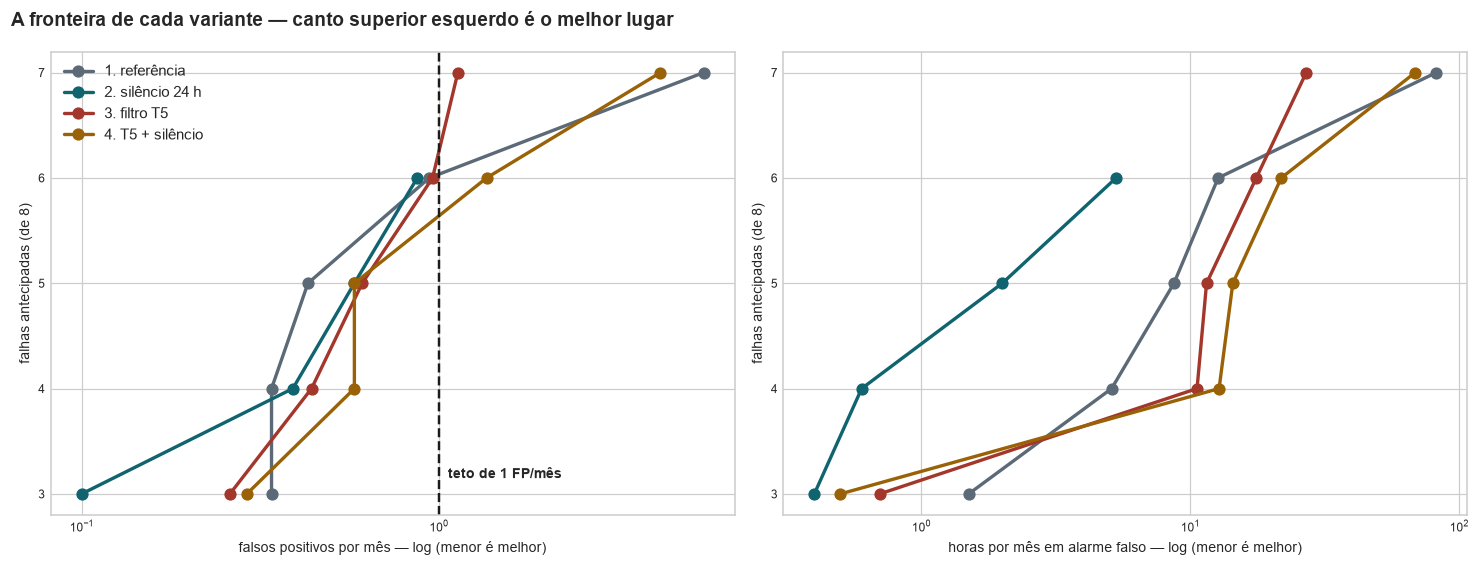

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2))
CORES = {"1. referência": "#5c6a78", "2. silêncio 24 h": "#0f6470",
         "3. filtro T5": "#a3372c", "4. T5 + silêncio": "#9a6207"}
for eixo, tabela, rotulo in ((ax1, fr_fp, "falsos positivos por mês"),
                             (ax2, fr_h, "horas por mês em alarme falso")):
    for nome in D:
        serie = tabela[nome].dropna()
        serie = serie[serie.index >= 3]
        eixo.plot(serie.values, serie.index, marker="o", ms=7, lw=2.2,
                  color=CORES[nome], label=nome)
    eixo.set_xscale("log"); eixo.set_xlabel(rotulo + " — log (menor é melhor)")
    eixo.set_ylabel("falhas antecipadas (de 8)"); eixo.set_yticks(range(3, 8))
ax1.axvline(TETO_FP, color="#1c1b18", ls="--", lw=1.6)
ax1.text(TETO_FP * 1.06, 3.15, "teto de 1 FP/mês", fontsize=9, fontweight="bold")
ax1.legend(frameon=False, fontsize=9.5, loc="upper left")
fig.suptitle("A fronteira de cada variante — canto superior esquerdo é o melhor lugar",
             fontsize=12.5, fontweight="bold", x=0.006, ha="left")
fig.tight_layout()
destino = RAIZ / "reports/figures/deteccao/fronteiras_quatro_variantes.png"
fig.savefig(destino, dpi=150, bbox_inches="tight"); print("figura:", destino)
plt.show()

## 3. O nível de 7 de 8

Nenhuma variante entrega 7/8 dentro do teto, mas a distância até lá muda muito.

In [5]:
sete = []
for nome, d in D.items():
    s = d[d.eventos_detectados >= 7]
    if s.empty:
        sete.append(dict(variante=nome, configs=0)); continue
    b = s.sort_values("fp_por_mes").iloc[0]
    sete.append(dict(variante=nome, configs=len(s), menor_fp=round(b.fp_por_mes, 2),
                     h_alarme_falso=round(b.fp_horas_por_mes, 1), lead_h=round(b.lead_medio_h, 1),
                     modelo=b["trial.model"], grade=b["trial.grid"],
                     trimestres=f"{int(b.trimestres_com_alerta)}/6"))
pd.DataFrame(sete).set_index("variante")

,configs,menor_fp,h_alarme_falso,lead_h,modelo,grade,trimestres
variante,,,,,,,
1. referência,26,5.51,99.4,22.9,ae,30s,6/6
2. silêncio 24 h,0,NaN,NaN,NaN,NaN,NaN,NaN
3. filtro T5,267,1.13,28.3,17.2,mahal,30s,4/6
4. T5 + silêncio,13,4.17,68.6,22.1,mahal,2min,5/6


**O achado desta rodada.** O filtro de temperatura não melhora o nível de 6/8 — mas
transforma o de 7/8: de 26 configurações a 5,51 FP/mês para **267 configurações a
1,13 FP/mês**, cinco vezes menos falso positivo, a 13% do teto. A falha extra é a de
**09/12/2025**, e todas as 267 são **Mahalanobis**, não PCA nem autoencoder.

Era a falha que o diagnóstico de precursor dava como invisível: nos 36 sensores, em três
horizontes, o desvio mais raro dela chegava ao percentil 87. O que o T5 fez foi tirar do
baseline as horas em que o `RUNNING_A` afirmava operação com a turbina fria — e, com esse
baseline, o Mahalanobis passa a enxergá-la com 7,6 h de antecedência.

## 4. As duas melhorias não se somam

Ligar T5 e silêncio juntos é a pior das quatro variantes.

In [6]:
resumo = pd.DataFrame({
    "melhor 6/8 dentro do teto (h/mês)": {n: (d[(d.eventos_detectados >= 6) & (d.fp_por_mes <= TETO_FP)]
                                              .fp_horas_por_mes.min()) for n, d in D.items()},
    "configs de 6/8 aprovadas": {n: int(((d.eventos_detectados >= 6) & (d.fp_por_mes <= TETO_FP)).sum())
                                 for n, d in D.items()},
    "menor FP no nível 7/8": {n: (d[d.eventos_detectados >= 7].fp_por_mes.min()
                                  if (d.eventos_detectados >= 7).any() else np.nan)
                              for n, d in D.items()}}).round(2)
resumo

,melhor 6/8 dentro do teto (h/mês),configs de 6/8 aprovadas,menor FP no nível 7/8
1. referência,18.1,7,5.51
2. silêncio 24 h,13.8,1,NaN
3. filtro T5,27.7,3,1.13
4. T5 + silêncio,NaN,0,4.17


**Por quê.** Os dois eixos removem coisas diferentes do mesmo lugar. O T5 tira do baseline
as horas de operação aparente com a turbina fria; o silêncio tira do alerta as 24 h após
cada partida — e essas janelas se sobrepõem, porque religar a máquina é exatamente quando
a exaustão está subindo. Juntos, removem tanta amostra que o limiar percentil desaba e o
falso positivo volta a subir. É o mesmo mecanismo que já tinha derrubado o descarte de
partida ampliado.

## 5. A mesma configuração nos quatro mundos

As linhas acima usam o melhor ponto de cada variante, e o modelo muda entre elas. Para
isolar o efeito da limpeza, a seção abaixo roda **a configuração de produção** — PCA,
2 min, p99,9, EWMA 2 h, 30 min de persistência, 2 sinais — nos quatro mundos.

In [7]:
CONFIG = dict(model="pca", grid="2min", exclude_days=0, exclude_alarm_h=1.0,
              ewma="2h", threshold=99.9, sustain="30min", confirm=2, min_alert="0min")
POLITICA = automl.BaselinePolicy(window_hours=3000)
CACHES = RAIZ / "data/interim/comparacao"; CACHES.mkdir(parents=True, exist_ok=True)

rodadas, placar = {}, []
for nome, v in VARIANTES.items():
    automl.EXHAUST_GATE, automl.EXHAUST_MIN_H = v["gate"], 1.0
    automl.STARTUP_EXCLUDE, automl.POST_START_SILENCE = "2h", v["silencio"]
    bundle = CachedBundle().build(); bundle._grids.clear(); bundle._trips = None
    cache = CACHES / f"final_{v['gate']}_{v['silencio']}"; cache.mkdir(exist_ok=True)
    r = DetectionReplay(bundle=bundle, cache_dir=cache).run(baseline=POLITICA, **CONFIG)
    rodadas[nome] = r; m = r.metrics
    placar.append(dict(variante=nome, eventos=f"{m['eventos_detectados']}/8",
                       lead_h=m["lead_medio_h"], fp_mes=m["fp_por_mes"],
                       h_alarme_falso=m["fp_horas_por_mes"], episodios=m["episodios_totais"],
                       dias=m["dias_avaliados"]))
automl.EXHAUST_GATE, automl.POST_START_SILENCE = "off", "0h"
pd.DataFrame(placar).set_index("variante")

[dados] cache replay_raw_68b25f9d.parquet: 1,396,800 amostras | 2025-01-01 00:00:00 → 2026-04-30 23:59:30


[alarmes] 132 episódios de alarme em operação (76 só de utilidade/gás) servirão de avaliação secundária


[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_2min_3000h_0_1.0_1d30ff1f.pkl


...

[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_2min_3000h_0_1.0_1d30ff1f.pkl


[replay] pca|2min|b3000h|excl0d|alm1.0h|ewma2h|q99.9|sust30min|conf2|min0min -> 5/8 eventos | lead 19.1 h | FP 1.94/mês


,eventos,lead_h,fp_mes,h_alarme_falso,episodios,dias
variante,,,,,,
1. referência,6/8,18.3,0.94,22.0,20,350.5
2. silêncio 24 h,6/8,18.3,0.87,13.8,17,311.4
3. filtro T5,5/8,19.5,2.00,42.7,33,345.3
4. T5 + silêncio,5/8,19.1,1.94,35.5,30,309.5


figura: /home/chico/Documentos/ciencia-dados/Cabiúnas/cabiunas_pdm/reports/figures/deteccao/quatro_variantes_serie.png


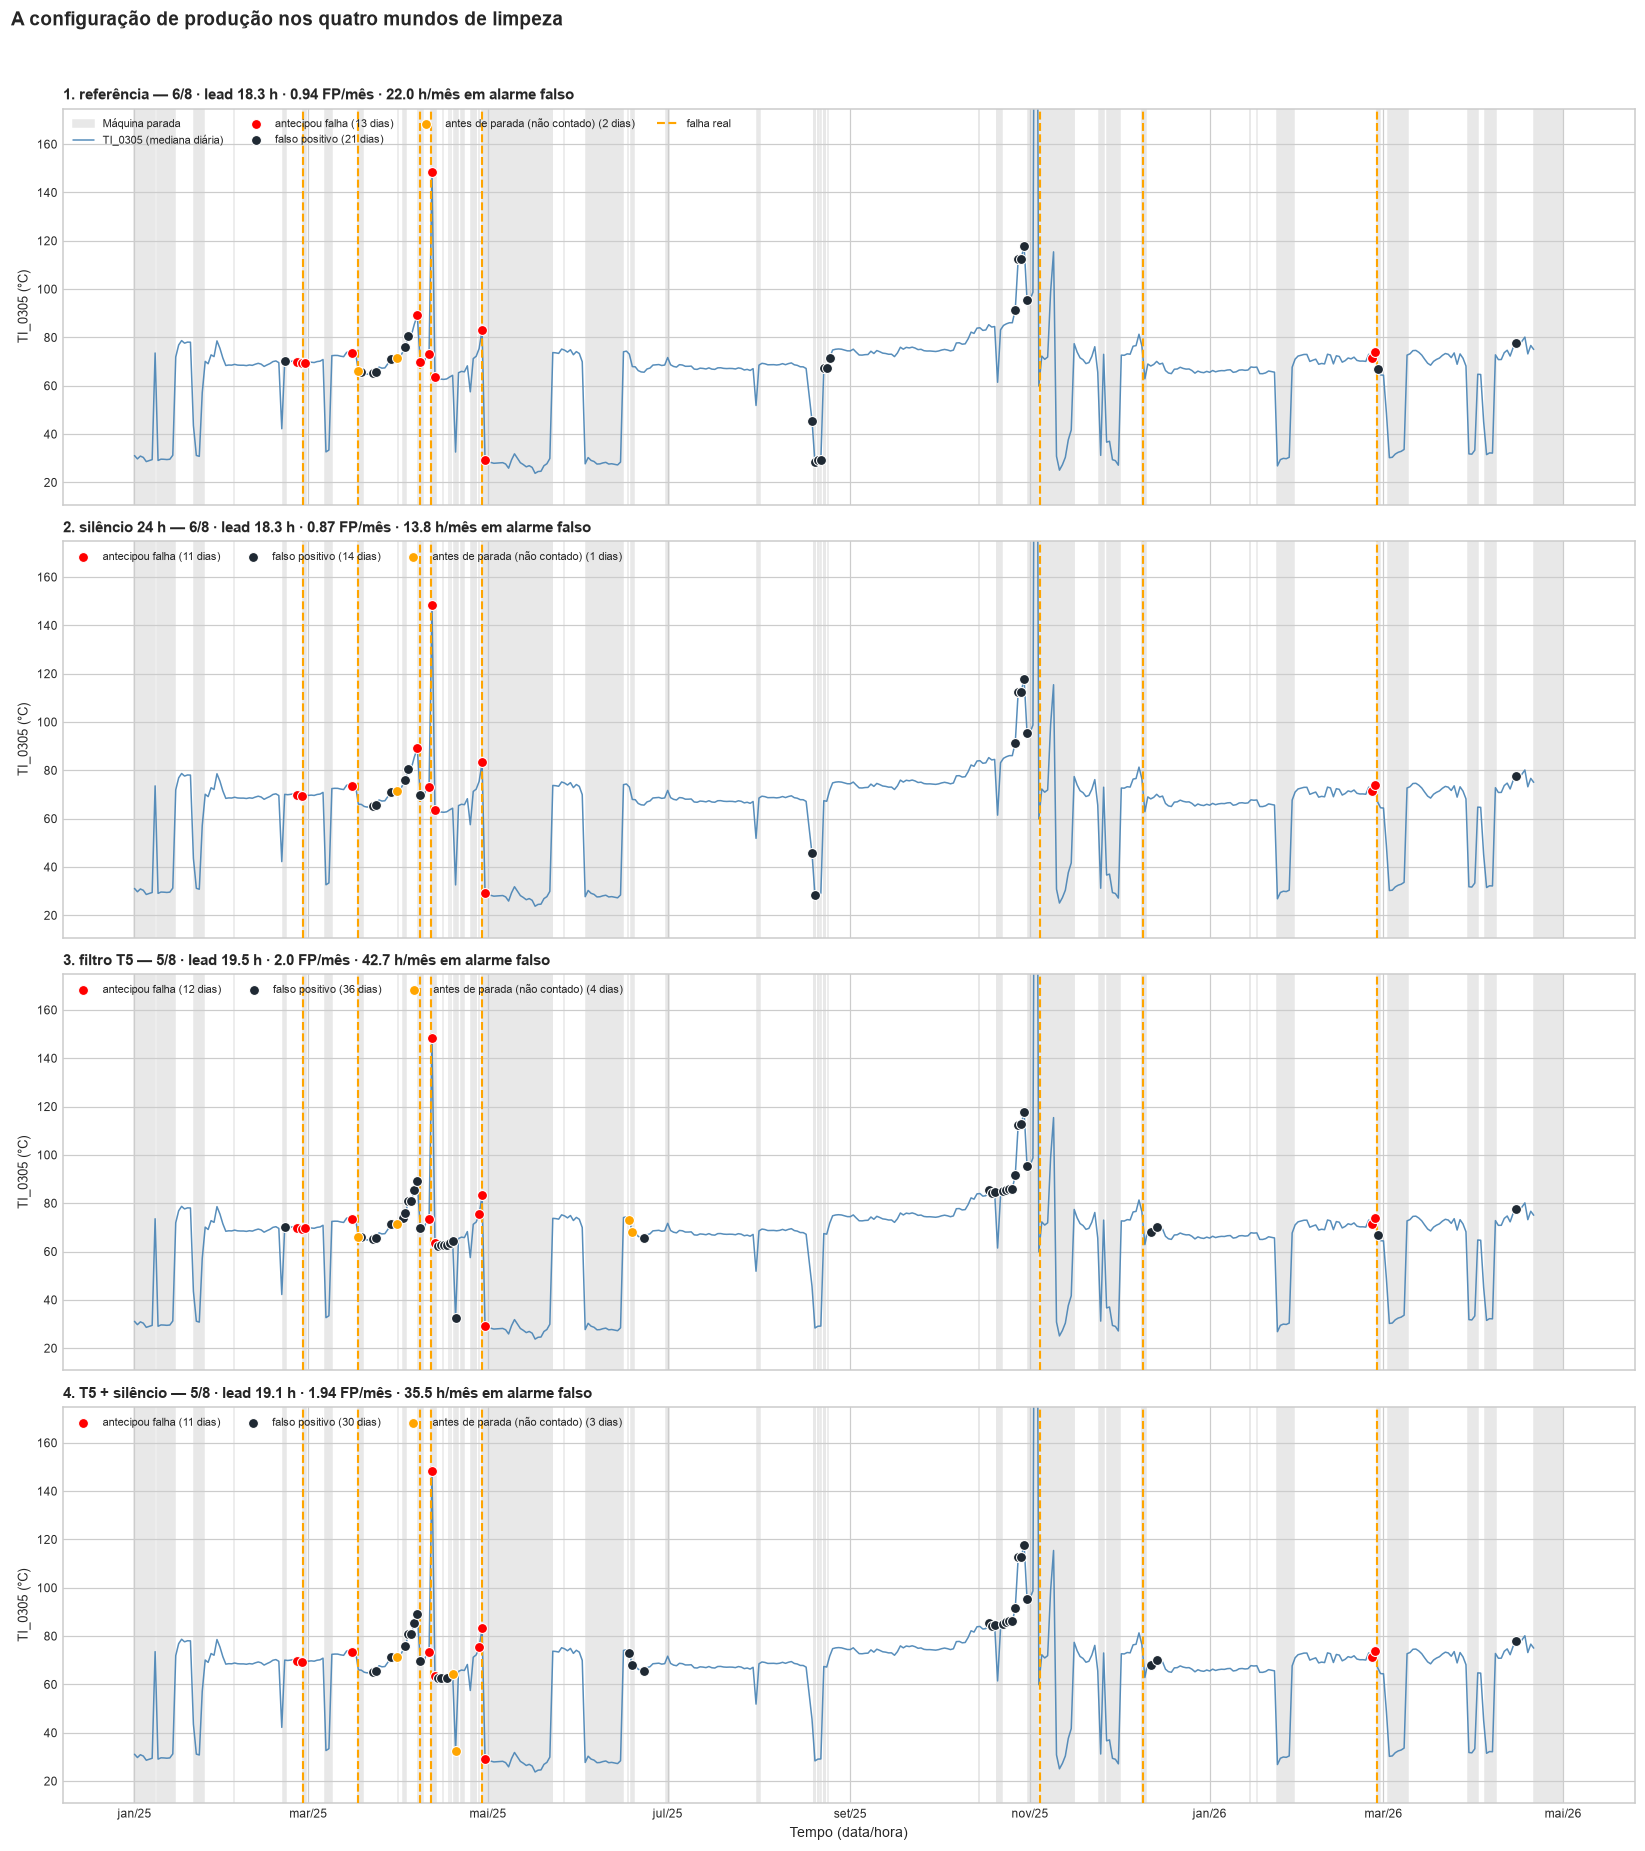

In [8]:
SENSOR, FREQ = "954005_624_TI_0305", "1D"
ROTULO = {"detecção": "antecipou falha", "falso positivo": "falso positivo",
          "antes de parada (não contado)": "antes de parada (não contado)"}
ref = viz.decimar(rodadas["1. referência"].sensors[SENSOR], FREQ, "median")
baixo, alto = np.nanpercentile(ref.dropna().to_numpy(), [0.2, 99.8]); margem = (alto - baixo) * 0.10

fig, axes = plt.subplots(len(rodadas), 1, figsize=(15, 4.2 * len(rodadas)), sharex=True)
for eixo, (nome, r) in zip(axes, rodadas.items()):
    m = r.metrics; s = viz.decimar(r.sensors[SENSOR], FREQ, "median")
    viz.sombrear_paradas(eixo, r.operability, FREQ, rotulo=(eixo is axes[0]))
    eixo.plot(s.index, s.to_numpy(), color=viz.COR_SERIE, lw=1.0, alpha=0.9,
              label="TI_0305 (mediana diária)" if eixo is axes[0] else None)
    for tipo, quando in viz.pontos_por_tipo(r, FREQ).items():
        v = s.reindex(quando).dropna()
        if v.empty: continue
        eixo.scatter(v.index, v.to_numpy(), s=42, zorder=6, color=viz.CORES_EPISODIO[tipo],
                     edgecolor="white", linewidth=0.7, label=f"{ROTULO[tipo]} ({len(v)} dias)")
    viz.marcar_eventos(eixo, r.events, rotulo="falha real" if eixo is axes[0] else None)
    eixo.set_ylim(baixo - margem, alto + margem); eixo.set_ylabel("TI_0305 (°C)", fontsize=8.5)
    eixo.set_title(f"{nome} — {m['eventos_detectados']}/8 · lead {m['lead_medio_h']} h · "
                   f"{m['fp_por_mes']} FP/mês · {m['fp_horas_por_mes']} h/mês em alarme falso",
                   loc="left", fontsize=10, fontweight="bold", pad=6)
    eixo.legend(loc="upper left", fontsize=7, ncol=4, framealpha=0.93)
axes[-1].set_xlabel("Tempo (data/hora)")
viz._formatar_eixo_x(axes[-1], ref.index)
fig.suptitle("A configuração de produção nos quatro mundos de limpeza",
             fontsize=12.5, fontweight="bold", x=0.006, ha="left", y=0.999)
fig.tight_layout(rect=[0, 0, 1, 0.985])
destino = RAIZ / "reports/figures/deteccao/quatro_variantes_serie.png"
fig.savefig(destino, dpi=150, bbox_inches="tight"); print("figura:", destino)
plt.show()

## 6. Veredito

| pergunta | resposta |
|---|---|
| melhor para operar hoje | **silêncio de 24 h** — 6/8, lead 18,3 h, 0,87 FP/mês e 13,8 h/mês em alarme falso, o menor de todos |
| melhor para chegar a 7/8 | **filtro T5** — 267 configurações a 1,13 FP/mês, contra 26 a 5,51 sem ele |
| combinar os dois | **não** — anula os dois ganhos: nenhuma configuração de 6/8 aprovada e o 7/8 volta a 4,17 FP/mês |
| filtro T5 sozinho no nível de 6/8 | não compensa: 0,96 FP/mês e 27,7 h/mês, pior que a referência |

**O que eu levaria para a operação:** o silêncio de 24 h como melhoria imediata, com a
ressalva de que ele deixa 15% do tempo de operação sem vigilância e reduz a uma única
configuração aprovada em 6/8.

**E uma pergunta para eles:** o filtro T5 põe 7 de 8 ao alcance por 1,13 FP/mês. Está 13%
acima do teto que **nós** definimos — e esse teto é convenção nossa, não requisito deles.
Se a operação tolerar um falso positivo a mais por mês, o detector passa a antecipar a
falha de 09/12/2025, que hoje é invisível para qualquer configuração da referência.

**Ressalva sobre essas 267 configurações:** todas são Mahalanobis, alarmam em 4 dos 6
trimestres (contra 6/6 da referência) e vêm de uma varredura só. Antes de propor troca de
arquitetura, vale confirmar que o ganho não é ruído de uma amostra de 8 eventos.

## 7. Comparação com o resultado da Lara

A configuração que a Lara apresentou (`fp_first — pca|2min|b3000h`) **está dentro da nossa
varredura**: é `pca | 2 min | EWMA 1 h | p99,995 | persistência 1 h | 2 sinais |
min_alert 30 min`. Não é um resultado pior nem melhor — é **outro ponto da mesma
fronteira**, que troca uma falha por menos alarme.

In [9]:
COMPARATIVO = pd.DataFrame([
    dict(configuracao="Lara — fp_first", falhas="5/8", lead_h=8.8, fp_mes=0.43, fp_liquido=0.34,
         h_alarme_falso=10.2, alarmes="7/132", total_alerta_h=342, dias=350.5,
         ponto="pca|2min|ewma1h|p99.995|sust1h|min30min"),
    dict(configuracao="produção atual", falhas="6/8", lead_h=18.3, fp_mes=0.94, fp_liquido=0.60,
         h_alarme_falso=22.0, alarmes="12/132", total_alerta_h=438, dias=350.5,
         ponto="pca|2min|ewma2h|p99.9|sust30min|min0min"),
    dict(configuracao="2º melhor sem silêncio", falhas="6/8", lead_h=11.8, fp_mes=0.95, fp_liquido=0.60,
         h_alarme_falso=18.1, alarmes="8/132", total_alerta_h=377, dias=348.6,
         ponto="pca|30s|ewma1h|p99.9|sust2h|min0min"),
    dict(configuracao="silêncio 24 h — mais detecção", falhas="6/8", lead_h=18.3, fp_mes=0.87,
         fp_liquido=0.48, h_alarme_falso=13.8, alarmes="11/132", total_alerta_h=255, dias=311.4,
         ponto="pca|2min|ewma2h|p99.9|sust30min|min0min"),
    dict(configuracao="silêncio 24 h — menos alarme", falhas="5/8", lead_h=8.5, fp_mes=0.58,
         fp_liquido=0.39, h_alarme_falso=2.0, alarmes="5/132", total_alerta_h=181, dias=311.4,
         ponto="pca|2min|ewma30min|p99.97|sust2h|min0min"),
]).set_index("configuracao")
COMPARATIVO

,falhas,lead_h,fp_mes,fp_liquido,h_alarme_falso,alarmes,total_alerta_h,dias,ponto
configuracao,,,,,,,,,
Lara — fp_first,5/8,8.8,0.43,0.34,10.2,7/132,342,350.5,pca|2min|ewma1h|p99.995|sust1h|min30min
produção atual,6/8,18.3,0.94,0.60,22.0,12/132,438,350.5,pca|2min|ewma2h|p99.9|sust30min|min0min
2º melhor sem silêncio,6/8,11.8,0.95,0.60,18.1,8/132,377,348.6,pca|30s|ewma1h|p99.9|sust2h|min0min
silêncio 24 h — mais detecção,6/8,18.3,0.87,0.48,13.8,11/132,255,311.4,pca|2min|ewma2h|p99.9|sust30min|min0min
silêncio 24 h — menos alarme,5/8,8.5,0.58,0.39,2.0,5/132,181,311.4,pca|2min|ewma30min|p99.97|sust2h|min0min


## 8. Ranqueando por "alarmar menos"

O critério da equipe é: **entre duas opções, prefere-se perder uma falha a incomodar a
operação com alarme falso**. Uma ressalva antes de aplicar: esse critério, sozinho, tem
ótimo degenerado — o detector mudo alarma zero e erra zero. Então ele só faz sentido
**dentro de um nível de detecção**: escolhido o quanto se aceita perder, minimiza-se o
alarme.

E aqui aparece o ponto que decide: **"alarmar menos" medido em episódios por mês dá um
vencedor; medido em horas de alarme por mês dá outro.**

In [10]:
niveis = []
for nivel in (7, 6, 5, 4):
    for nome, d in D.items():
        s = d[d.eventos_detectados == nivel]
        if s.empty:
            continue
        b_ep = s.sort_values("fp_por_mes").iloc[0]
        b_h = s.sort_values("fp_horas_por_mes").iloc[0]
        niveis.append(dict(falhas=f"{nivel}/8", variante=nome,
                           menor_fp_mes=round(b_ep.fp_por_mes, 2),
                           h_desse_ponto=round(b_ep.fp_horas_por_mes, 1),
                           menor_h_mes=round(b_h.fp_horas_por_mes, 1),
                           fp_desse_ponto=round(b_h.fp_por_mes, 2)))
pd.DataFrame(niveis).set_index(["falhas", "variante"])

menor_fp_mes  h_desse_ponto  menor_h_mes  fp_desse_ponto
falhas variante                                                                  
7/8    1. referência             5.51           99.4         82.2            5.59
       3. filtro T5              1.13           28.3         27.0            1.13
       4. T5 + silêncio          4.17           68.6         68.6            4.17
6/8    1. referência             0.94           22.0         12.7            1.28
       2. silêncio 24 h          0.87           13.8          5.3            1.54
       3. filtro T5              0.96           27.7         17.6            2.17
       4. T5 + silêncio          1.36           32.3         21.8            1.74
5/8    1. referência             0.43           10.1          8.7            0.52
       2. silêncio 24 h          0.58            2.1          2.0            0.58
       3. filtro T5              0.61           15.3         11.5            1.05
       4. T5 + silêncio          0.58           17.6         14.4            1.16
4/8    1. referência             0.34           22.1          5.1            1.37
       2. silêncio 24 h          0.39           13.4          0.6            0.58
       3. filtro T5              0.44           10.8         10.6            0.44
       4. T5 + silêncio          0.58           17.2         12.8            0.68

**Leitura, no critério da equipe.**

Se "alarmar menos" for **episódios por mês**, o ponto da Lara é o melhor em 5/8:
0,43 FP/mês contra 0,58 do silêncio.

Se for **horas em alarme falso** — que é o que a operação de fato sente, porque um alarme
travado por 100 h conta como um único episódio —, o silêncio de 24 h em 5/8 ganha por
cinco vezes: **2,0 h/mês contra 10,2 h/mês**. E o tempo total em alerta cai de 342 h para
181 h no período inteiro.

**A recomendação sob esse critério:** `pca | 2 min | EWMA 30 min | p99,97 | persistência
2 h | 2 sinais`, com silêncio de 24 h — 5 de 8 falhas, 8,5 h de antecedência, 0,58 FP/mês
e **2,0 h/mês em alarme falso**. É a opção que menos incomoda a operação entre todas as
41.472 configurações avaliadas nas quatro varreduras.

O preço é explícito: perde-se a falha de 26/02/2026 em relação ao ponto de 6/8, e a
antecedência cai de 18,3 h para 8,5 h — de dois turnos para um.

**Se o silêncio for questionado**, o plano B no mesmo critério é o ponto da Lara:
0,43 FP/mês e 10,2 h/mês, sem filtro nenhum, 5 de 8.

## 9. Os três finalistas, lado a lado

Ranqueados pelo critério da equipe — **alarmar menos**, medido em horas de alarme falso —
no mesmo nível de detecção (5 de 8). O segundo colocado **não** é o ponto da Lara: é uma
configuração de 30 s da própria varredura de referência, que alarma menos horas que ela
sem precisar de filtro nenhum.

In [11]:
FINALISTAS = [
    ("1º  silêncio 24 h", "pca|2min|ewma30min|p99.97|sust2h|conf2|min0min  + silêncio 24 h",
     dict(falhas=5, lead=8.5, fp=0.58, fp_liq=0.39, horas=2.0, alarmes=5, dias=311.4,
          total=181, det=5, falso=6, antes=2)),
    ("2º  30 s, sem filtro", "pca|30s|ewma30min|p99.995|sust1h|conf2|min30min",
     dict(falhas=5, lead=9.0, fp=0.52, fp_liq=0.34, horas=8.7, alarmes=8, dias=348.6,
          total=268, det=6, falso=6, antes=2)),
    ("3º  Lara (fp_first)", "pca|2min|ewma1h|p99.995|sust1h|conf2|min30min",
     dict(falhas=5, lead=8.8, fp=0.43, fp_liq=0.34, horas=10.2, alarmes=7, dias=350.5,
          total=342, det=6, falso=5, antes=3)),
]

for titulo, ponto, p in FINALISTAS:
    print(f"PLACAR — {titulo}")
    print(f"  {ponto}")
    print(f"  falhas antecipadas ........ {p['falhas']} de 8")
    print(f"  antecedência média ........ {p['lead']} h")
    print(f"  falso positivo ............ {p['fp']}/mês  (líquido {p['fp_liq']}/mês, "
          f"descontando os que coincidem com alarme ativo)")
    print(f"  tempo em alarme falso ..... {p['horas']} h/mês")
    print(f"  episódios de alarme antecipados ... {p['alarmes']}/132 (avaliação secundária)")
    print(f"  dias de operação avaliados ........ {p['dias']}")
    print()
    print(f"  tempo TOTAL em alerta no período: {p['total']} h "
          f"({p['total']/24:.1f} dias equivalentes)")
    print()
    print(f"                              episódios")
    print(f"                        tipo")
    print(f"                   detecção   {p['det']:>7}")
    print(f"             falso positivo   {p['falso']:>7}")
    print(f"  antes de parada (não contado) {p['antes']:>5}")
    print("\n" + "─" * 78 + "\n")

PLACAR — 1º  silêncio 24 h
  pca|2min|ewma30min|p99.97|sust2h|conf2|min0min  + silêncio 24 h
  falhas antecipadas ........ 5 de 8
  antecedência média ........ 8.5 h
  falso positivo ............ 0.58/mês  (líquido 0.39/mês, descontando os que coincidem com alarme ativo)
  tempo em alarme falso ..... 2.0 h/mês
  episódios de alarme antecipados ... 5/132 (avaliação secundária)
  dias de operação avaliados ........ 311.4

  tempo TOTAL em alerta no período: 181 h (7.5 dias equivalentes)

                              episódios
                        tipo
                   detecção         5
             falso positivo         6
  antes de parada (não contado)     2

──────────────────────────────────────────────────────────────────────────────

PLACAR — 2º  30 s, sem filtro
  pca|30s|ewma30min|p99.995|sust1h|conf2|min30min
  falhas antecipadas ........ 5 de 8
  antecedência média ........ 9.0 h
  falso positivo ............ 0.52/mês  (líquido 0.34/mês, descontando os que coincidem com 

figura: /home/chico/Documentos/ciencia-dados/Cabiúnas/cabiunas_pdm/reports/figures/deteccao/tres_finalistas.png


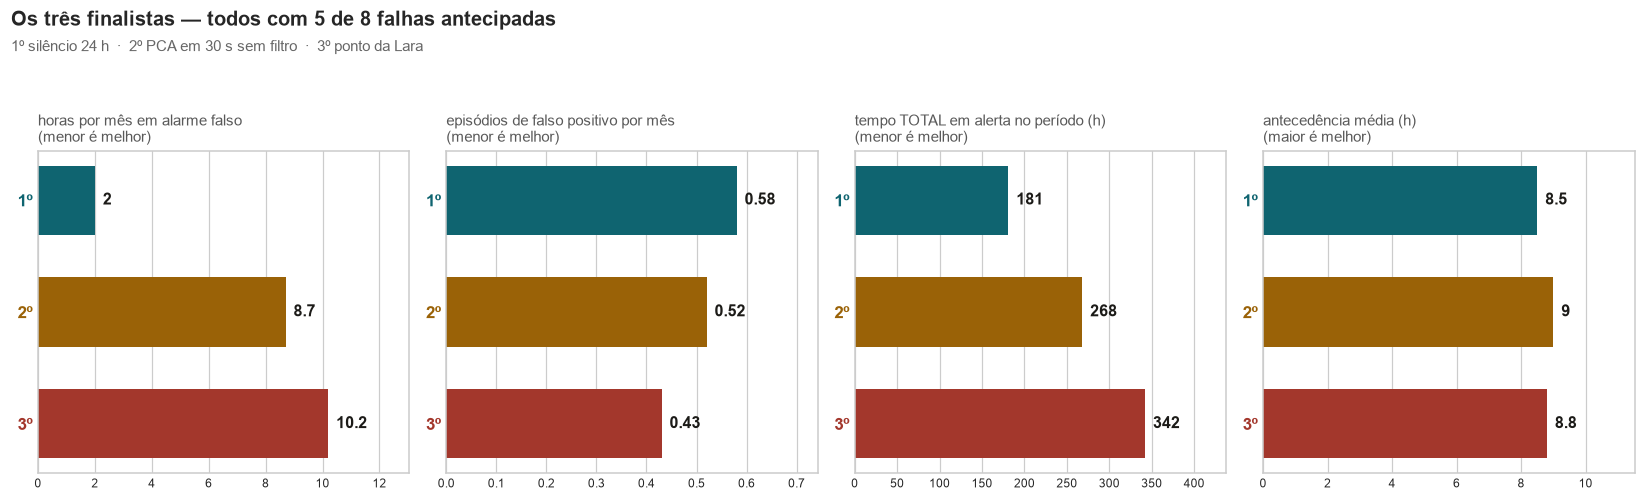

In [12]:
dados = pd.DataFrame([dict(config=t.split("  ", 1)[1], ordem=t.split("  ")[0], **p)
                      for t, _, p in FINALISTAS])
COR = {"1º": "#0f6470", "2º": "#9a6207", "3º": "#a3372c"}
cores = [COR[o] for o in dados.ordem]

fig, axes = plt.subplots(1, 4, figsize=(15, 4.6))
PAINEIS = [("horas", "horas por mês em alarme falso", False),
           ("fp", "episódios de falso positivo por mês", False),
           ("total", "tempo TOTAL em alerta no período (h)", False),
           ("lead", "antecedência média (h)", True)]
for eixo, (coluna, titulo, maior_melhor) in zip(axes, PAINEIS):
    y = range(len(dados))[::-1]
    eixo.barh(list(y), dados[coluna], color=cores, height=0.62)
    for yy, (_, l) in zip(y, dados.iterrows()):
        eixo.text(l[coluna], yy, f"  {l[coluna]:g}", va="center", fontsize=10.5,
                  fontweight="bold", color="#1c1b18")
    eixo.set_yticks(list(y)); eixo.set_yticklabels(dados.ordem, fontsize=11, fontweight="bold")
    for tick, c in zip(eixo.get_yticklabels(), cores):
        tick.set_color(c)
    eixo.set_title(titulo + ("\n(maior é melhor)" if maior_melhor else "\n(menor é melhor)"),
                   fontsize=9.5, loc="left", color="0.35")
    eixo.set_xlim(0, dados[coluna].max() * 1.28)
    eixo.grid(axis="y", visible=False)

fig.suptitle("Os três finalistas — todos com 5 de 8 falhas antecipadas",
             fontsize=13, fontweight="bold", x=0.006, ha="left")
fig.text(0.006, 0.90, "1º silêncio 24 h  ·  2º PCA em 30 s sem filtro  ·  3º ponto da Lara",
         fontsize=10, color="0.4")
fig.tight_layout(rect=[0, 0, 1, 0.88])
destino = RAIZ / "reports/figures/deteccao/tres_finalistas.png"
fig.savefig(destino, dpi=150, bbox_inches="tight"); print("figura:", destino)
plt.show()

**Como ler.** Os três antecipam as mesmas 5 falhas. A diferença está no incômodo:

- em **horas de alarme falso**, o silêncio ganha por 4 a 5 vezes — 2,0 h/mês contra 8,7 e
  10,2;
- em **episódios por mês**, a ordem se inverte e o ponto da Lara é o menor — 0,43 contra
  0,52 e 0,58. São três episódios a mais no período inteiro, mas muito mais curtos;
- em **tempo total em alerta**, que soma detecção e falso positivo, o silêncio marca 181 h
  contra 342 h do ponto da Lara — quase metade.

**O segundo colocado é o achado prático:** `pca | 30 s | EWMA 30 min | p99,995 |
persistência 1 h | min_alert 30 min`, **sem filtro nenhum**, alarma 8,7 h/mês contra
10,2 h/mês do ponto da Lara, com a mesma detecção e a mesma antecedência. Se o silêncio
for questionado na reunião, é para ele que se cai — e ele não depende de nenhuma decisão
polêmica, só de trocar a grade para 30 s e o ponto de operação.

### A série dos três finalistas

O mesmo sensor e o mesmo eixo de tempo nos três, um ponto por dia com alerta confirmado.
A régua verde no primeiro painel marca as 24 h silenciadas após cada partida.

[dados] cache replay_raw_68b25f9d.parquet: 1,396,800 amostras | 2025-01-01 00:00:00 → 2026-04-30 23:59:30


[alarmes] 132 episódios de alarme em operação (76 só de utilidade/gás) servirão de avaliação secundária


[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_2min_3000h_0_1.0_1d30ff1f.pkl


...

[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_2min_3000h_0_1.0_1d30ff1f.pkl


[replay] pca|2min|b3000h|excl0d|alm1.0h|ewma1h|q99.995|sust1h|conf2|min30min -> 5/8 eventos | lead 8.8 h | FP 0.43/mês


figura: /home/chico/Documentos/ciencia-dados/Cabiúnas/cabiunas_pdm/reports/figures/deteccao/tres_finalistas_serie.png


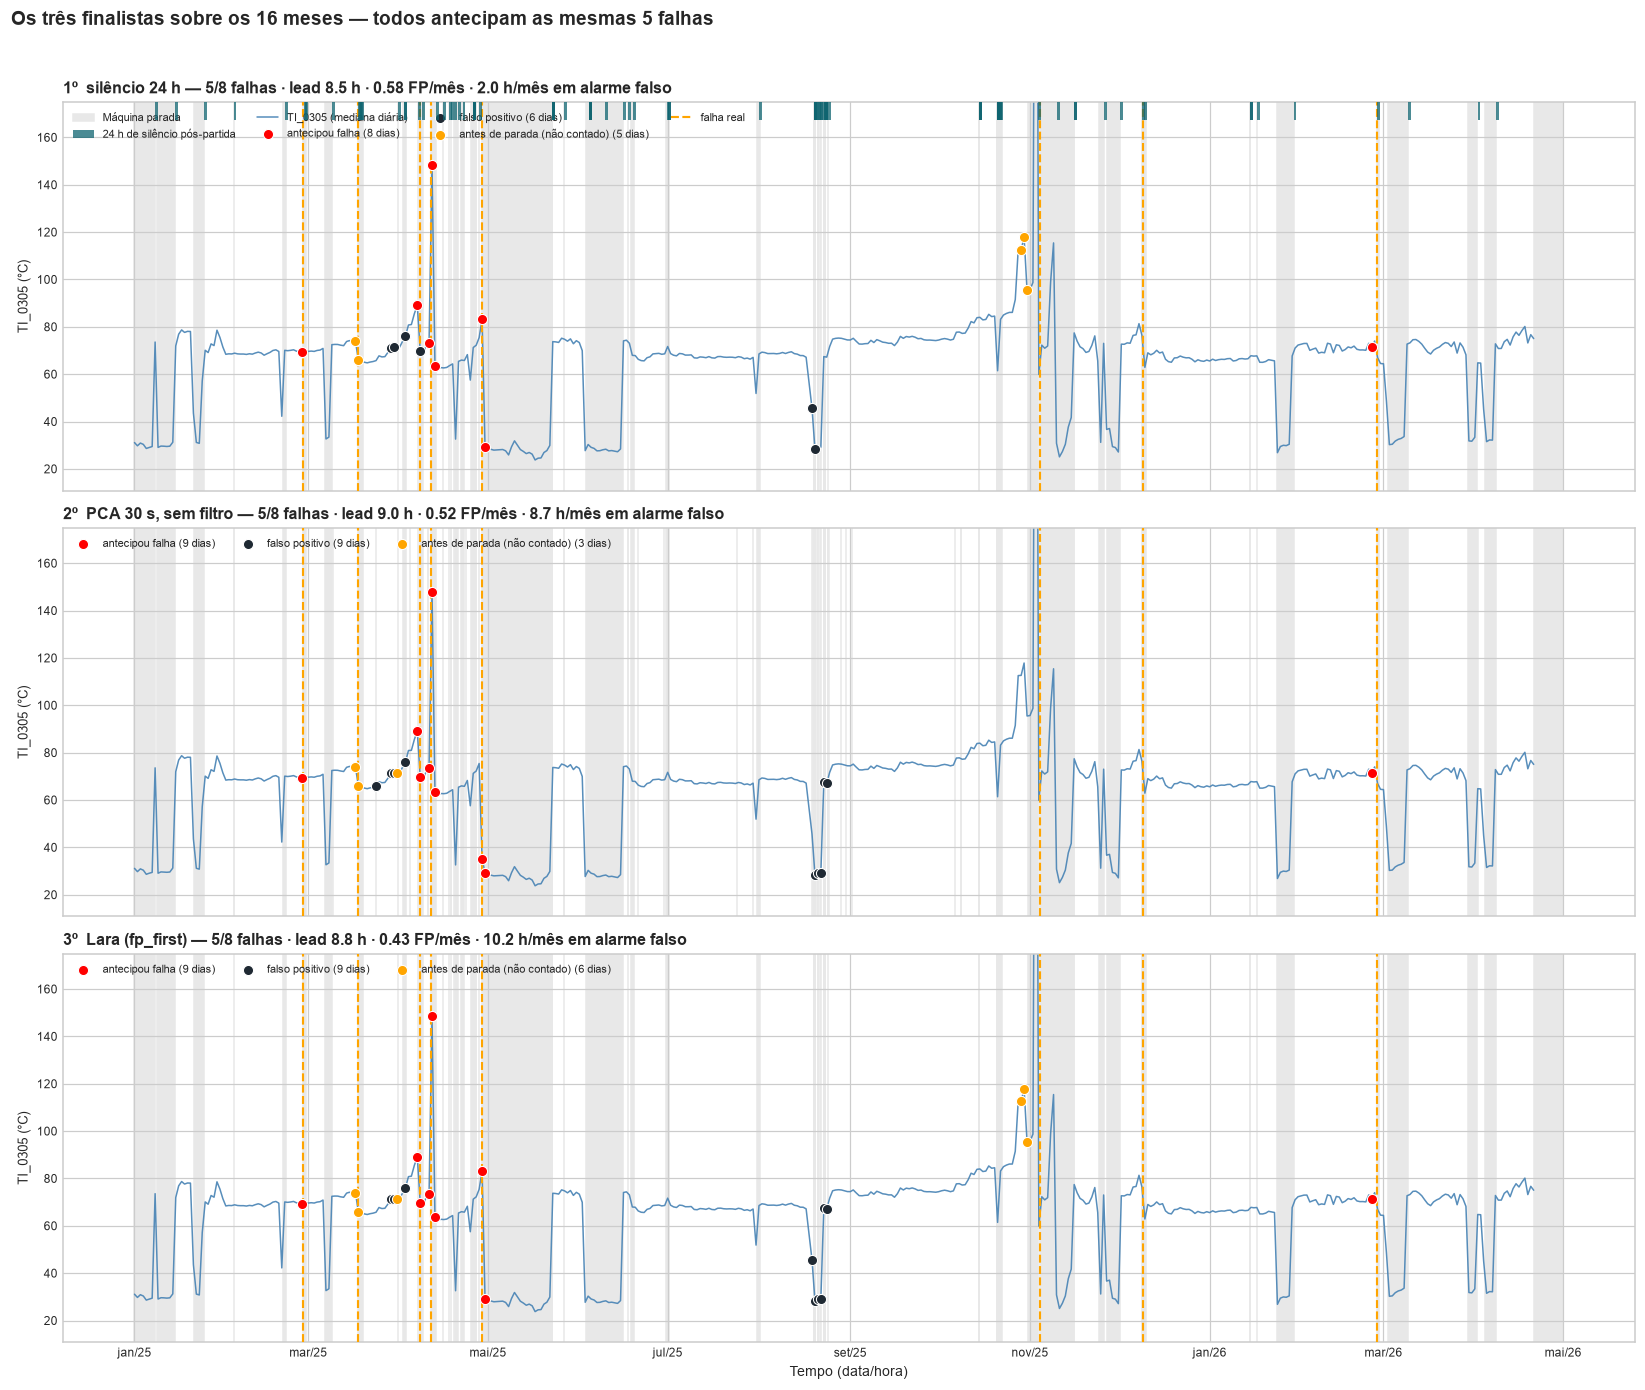

In [13]:

CONFIG_FINALISTAS = [
    ("1º  silêncio 24 h", "24h",
     dict(model="pca", grid="2min", ewma="30min", threshold=99.97, sustain="2h",
          confirm=2, min_alert="0min", exclude_days=0, exclude_alarm_h=1.0)),
    ("2º  PCA 30 s, sem filtro", "0h",
     dict(model="pca", grid="30s", ewma="30min", threshold=99.995, sustain="1h",
          confirm=2, min_alert="30min", exclude_days=0, exclude_alarm_h=1.0)),
    ("3º  Lara (fp_first)", "0h",
     dict(model="pca", grid="2min", ewma="1h", threshold=99.995, sustain="1h",
          confirm=2, min_alert="30min", exclude_days=0, exclude_alarm_h=1.0)),
]
fin = {}
for nome, silencio, cfg in CONFIG_FINALISTAS:
    automl.EXHAUST_GATE, automl.STARTUP_EXCLUDE, automl.POST_START_SILENCE = "off", "2h", silencio
    bundle = CachedBundle().build(); bundle._grids.clear(); bundle._trips = None
    cache = CACHES / f"placar_{silencio}"; cache.mkdir(exist_ok=True)
    fin[nome] = DetectionReplay(bundle=bundle, cache_dir=cache).run(baseline=POLITICA, **cfg)
automl.POST_START_SILENCE = "0h"

fig, axes = plt.subplots(3, 1, figsize=(15, 12.6), sharex=True)
for eixo, (nome, r) in zip(axes, fin.items()):
    m = r.metrics
    s = viz.decimar(r.sensors[SENSOR], FREQ, "median")
    viz.sombrear_paradas(eixo, r.operability, FREQ, rotulo=(eixo is axes[0]))
    if nome.startswith("1º"):
        operando = r.operability["in_operation"].astype(bool)
        partidas = operando & ~operando.shift(fill_value=False)
        primeiro = True
        for t0 in partidas[partidas].index:
            eixo.axvspan(t0, t0 + pd.Timedelta("24h"), ymin=0.955, ymax=1.0, lw=0,
                         color="#0f6470", alpha=0.75, zorder=8,
                         label="24 h de silêncio pós-partida" if primeiro else None)
            primeiro = False
    eixo.plot(s.index, s.to_numpy(), color=viz.COR_SERIE, lw=1.0, alpha=0.9,
              label="TI_0305 (mediana diária)" if eixo is axes[0] else None)
    for tipo, quando in viz.pontos_por_tipo(r, FREQ).items():
        v = s.reindex(quando).dropna()
        if v.empty:
            continue
        eixo.scatter(v.index, v.to_numpy(), s=44, zorder=6, color=viz.CORES_EPISODIO[tipo],
                     edgecolor="white", linewidth=0.7, label=f"{ROTULO[tipo]} ({len(v)} dias)")
    viz.marcar_eventos(eixo, r.events, rotulo="falha real" if eixo is axes[0] else None)
    eixo.set_ylim(baixo - margem, alto + margem)
    eixo.set_ylabel("TI_0305 (°C)", fontsize=8.5)
    eixo.set_title(f"{nome} — {m['eventos_detectados']}/8 falhas · lead {m['lead_medio_h']} h · "
                   f"{m['fp_por_mes']} FP/mês · {m['fp_horas_por_mes']} h/mês em alarme falso",
                   loc="left", fontsize=10.5, fontweight="bold", pad=6)
    eixo.legend(loc="upper left", fontsize=7, ncol=4, framealpha=0.93)
axes[-1].set_xlabel("Tempo (data/hora)")
viz._formatar_eixo_x(axes[-1], s.index)
fig.suptitle("Os três finalistas sobre os 16 meses — todos antecipam as mesmas 5 falhas",
             fontsize=12.5, fontweight="bold", x=0.006, ha="left", y=0.999)
fig.tight_layout(rect=[0, 0, 1, 0.985])
destino = RAIZ / "reports/figures/deteccao/tres_finalistas_serie.png"
fig.savefig(destino, dpi=150, bbox_inches="tight"); print("figura:", destino)
plt.show()


## 10. O silêncio de 12 h

Acrescentado depois: a varredura completa do silêncio de 12 h
(`automl-fp-first-policy_fine-silencio12h`, 10.368 configurações, 27/08/2026). Ela mudou a
conclusão anterior deste notebook.

Nas medições locais o 12 h parecia inviável em 6/8, porque a amostra que eu tinha varrido
cobria só a grade de 2 min, e ali silenciar 12 h parte os episódios longos ao meio: a
contagem de episódios sobe enquanto o denominador cai. **Na grade de 30 s isso não
acontece**, e o 12 h passa no teto com folga.

In [14]:

VARIANTES_FINAL = {
    "sem filtro (referência)": "res_baseline.parquet",
    "silêncio 12 h":           "res_silencio12h.parquet",
    "silêncio 24 h":           "res_silencio_v2.parquet",
    "filtro T5":               "res_t5gate.parquet",
    "T5 + silêncio 24 h":      "res_t5_silencio.parquet",
}
DF = {n: pd.read_parquet(AUTOML / a) for n, a in VARIANTES_FINAL.items() if (AUTOML / a).exists()}

def melhor_em(nivel):
    linhas = []
    for nome, d in DF.items():
        s = d[(d.eventos_detectados == nivel) & (d.fp_por_mes <= TETO_FP)]
        if s.empty:
            linhas.append(dict(variante=nome, situacao="nenhuma dentro do teto")); continue
        b = s.sort_values("fp_horas_por_mes").iloc[0]
        linhas.append(dict(variante=nome, lead_h=round(b.lead_medio_h, 1),
                           fp_mes=round(b.fp_por_mes, 2), fp_liquido=round(b.fp_por_mes_liquido, 2),
                           h_alarme_falso=round(b.fp_horas_por_mes, 1),
                           dias=round(b.dias_avaliados, 1),
                           trimestres=f"{int(b.trimestres_com_alerta)}/6",
                           configs_aprovadas=int(((d.eventos_detectados == nivel)
                                                  & (d.fp_por_mes <= TETO_FP)).sum()),
                           ponto=f"{b['trial.model']}|{b['trial.grid']}|p{b['trial.threshold']}"
                                 f"|{b['trial.ewma']}|{b['trial.sustain']}|min{b['trial.min_alert']}"))
    return pd.DataFrame(linhas).set_index("variante")

print("6 de 8 falhas, dentro do teto de 1 FP/mês:")
display(melhor_em(6))
print("5 de 8 falhas, dentro do teto de 1 FP/mês:")
display(melhor_em(5))


6 de 8 falhas, dentro do teto de 1 FP/mês:


,lead_h,fp_mes,fp_liquido,h_alarme_falso,dias,trimestres,configs_aprovadas,ponto,situacao
variante,,,,,,,,,
sem filtro (referência),11.8,0.95,0.60,18.1,348.6,6/6,7.0,pca|30s|p99.9|1h|2h|min0min,NaN
silêncio 12 h,11.8,0.93,0.74,13.2,322.6,6/6,6.0,pca|30s|p99.9|1h|2h|min0min,NaN
silêncio 24 h,18.3,0.87,0.48,13.8,311.4,6/6,1.0,pca|2min|p99.9|2h|30min|min0min,NaN
filtro T5,7.3,0.96,0.52,27.7,343.9,5/6,3.0,mahal|30s|p99.9|1h|1h|min30min,NaN
T5 + silêncio 24 h,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nenhuma dentro do teto


5 de 8 falhas, dentro do teto de 1 FP/mês:


,lead_h,fp_mes,fp_liquido,h_alarme_falso,dias,trimestres,configs_aprovadas,ponto
variante,,,,,,,,
sem filtro (referência),9.0,0.52,0.34,8.7,348.6,4/6,96,pca|30s|p99.995|30min|1h|min30min
silêncio 12 h,9.0,0.56,0.46,3.3,322.6,4/6,91,pca|30s|p99.995|30min|1h|min30min
silêncio 24 h,8.5,0.58,0.39,2.0,311.4,5/6,61,pca|2min|p99.97|30min|2h|min0min
filtro T5,11.2,0.96,0.61,14.2,343.9,5/6,17,pca|30s|p99.9|30min|1h|min30min
T5 + silêncio 24 h,11.3,0.97,0.58,16.4,309.5,5/6,8,pca|2min|p99.9|30min|1h|min30min


**O que muda.** Em 6 de 8, o silêncio de 12 h entrega **13,2 h/mês** em alarme falso contra
13,8 do 24 h e 18,1 sem filtro, cegando **7,5% do tempo de operação** em vez de 11%. E o
mais relevante para robustez: são **6 configurações aprovadas** contra **1** do 24 h.

O 24 h continua ganhando em duas coisas: antecedência de 18,3 h contra 11,8, e falso
positivo líquido de 0,48 contra 0,74.

Em 5 de 8, a ordem se mantém: 24 h com 2,0 h/mês, 12 h com 3,3 e sem filtro com 8,7.

figura: /home/chico/Documentos/ciencia-dados/Cabiúnas/cabiunas_pdm/reports/figures/deteccao/silencio_12h_vs_24h.png


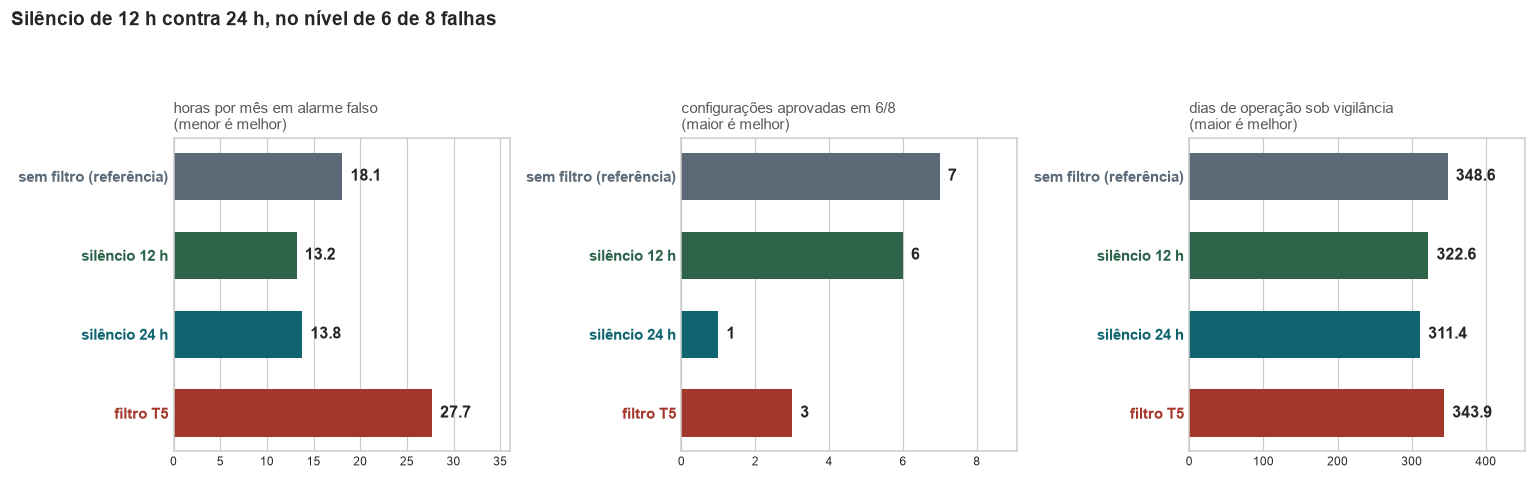

In [15]:

ordem = ["sem filtro (referência)", "silêncio 12 h", "silêncio 24 h", "filtro T5"]
seis = melhor_em(6).reindex(ordem).dropna(subset=["h_alarme_falso"])
COR = {"sem filtro (referência)": "#5c6a78", "silêncio 12 h": "#2c6349",
       "silêncio 24 h": "#0f6470", "filtro T5": "#a3372c"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
PAINEIS = [("h_alarme_falso", "horas por mês em alarme falso", "menor é melhor"),
           ("configs_aprovadas", "configurações aprovadas em 6/8", "maior é melhor"),
           ("dias", "dias de operação sob vigilância", "maior é melhor")]
for eixo, (coluna, titulo, sentido) in zip(axes, PAINEIS):
    y = list(range(len(seis)))[::-1]
    cores = [COR[i] for i in seis.index]
    eixo.barh(y, seis[coluna], color=cores, height=0.6)
    for yy, (_, l) in zip(y, seis.iterrows()):
        eixo.text(l[coluna], yy, f"  {l[coluna]:g}", va="center", fontsize=10.5, fontweight="bold")
    eixo.set_yticks(y); eixo.set_yticklabels(seis.index, fontsize=9.5)
    for tick, c in zip(eixo.get_yticklabels(), cores):
        tick.set_color(c); tick.set_fontweight("bold")
    eixo.set_title(f"{titulo}\n({sentido})", loc="left", fontsize=9.5, color="0.35")
    eixo.set_xlim(0, seis[coluna].max() * 1.3); eixo.grid(axis="y", visible=False)
fig.suptitle("Silêncio de 12 h contra 24 h, no nível de 6 de 8 falhas",
             fontsize=12.5, fontweight="bold", x=0.006, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.9])
destino = RAIZ / "reports/figures/deteccao/silencio_12h_vs_24h.png"
fig.savefig(destino, dpi=150, bbox_inches="tight"); print("figura:", destino)
plt.show()


**Correção do veredito deste notebook.** A seção 6 recomendava o silêncio de 24 h. Com a
varredura de 12 h em mãos, a recomendação passa a ser **12 h**:

| | 12 h | 24 h |
|---|---|---|
| horas em alarme falso | **13,2** | 13,8 |
| tempo cego | **7,5%** | 11% |
| configurações aprovadas em 6/8 | **6** | 1 |
| antecedência | 11,8 h | **18,3 h** |
| FP líquido | 0,74 | **0,48** |

O argumento decisivo é a robustez: com 24 h sobra **uma única** configuração viável, e um
detector que depende de um ponto do grid é frágil a qualquer mudança de regime do
equipamento. Com 12 h existem seis, e ainda se cega menos tempo.

Se a prioridade for antecedência, o 24 h continua na mesa: 18,3 h contra 11,8 é a
diferença entre dois turnos e um.

### A série: 12 h contra 24 h

Cada painel usa o **melhor ponto daquela variante em 6 de 8**, que não é o mesmo em todas:
sem filtro e com 12 h o vencedor está na grade de 30 s, com 24 h está em 2 min. A régua no
topo marca as janelas silenciadas, e dá para ver a diferença de densidade entre 12 e 24 h.

[dados] cache replay_raw_68b25f9d.parquet: 1,396,800 amostras | 2025-01-01 00:00:00 → 2026-04-30 23:59:30


[alarmes] 132 episódios de alarme em operação (76 só de utilidade/gás) servirão de avaliação secundária


[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_30s_3000h_0_1.0_7ca9455f.pkl


...

[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_2min_3000h_0_1.0_1d30ff1f.pkl


[replay] pca|2min|b3000h|excl0d|alm1.0h|ewma2h|q99.9|sust30min|conf2|min0min -> 6/8 eventos | lead 18.3 h | FP 0.87/mês


figura: /home/chico/Documentos/ciencia-dados/Cabiúnas/cabiunas_pdm/reports/figures/deteccao/silencio_12h_24h_serie.png


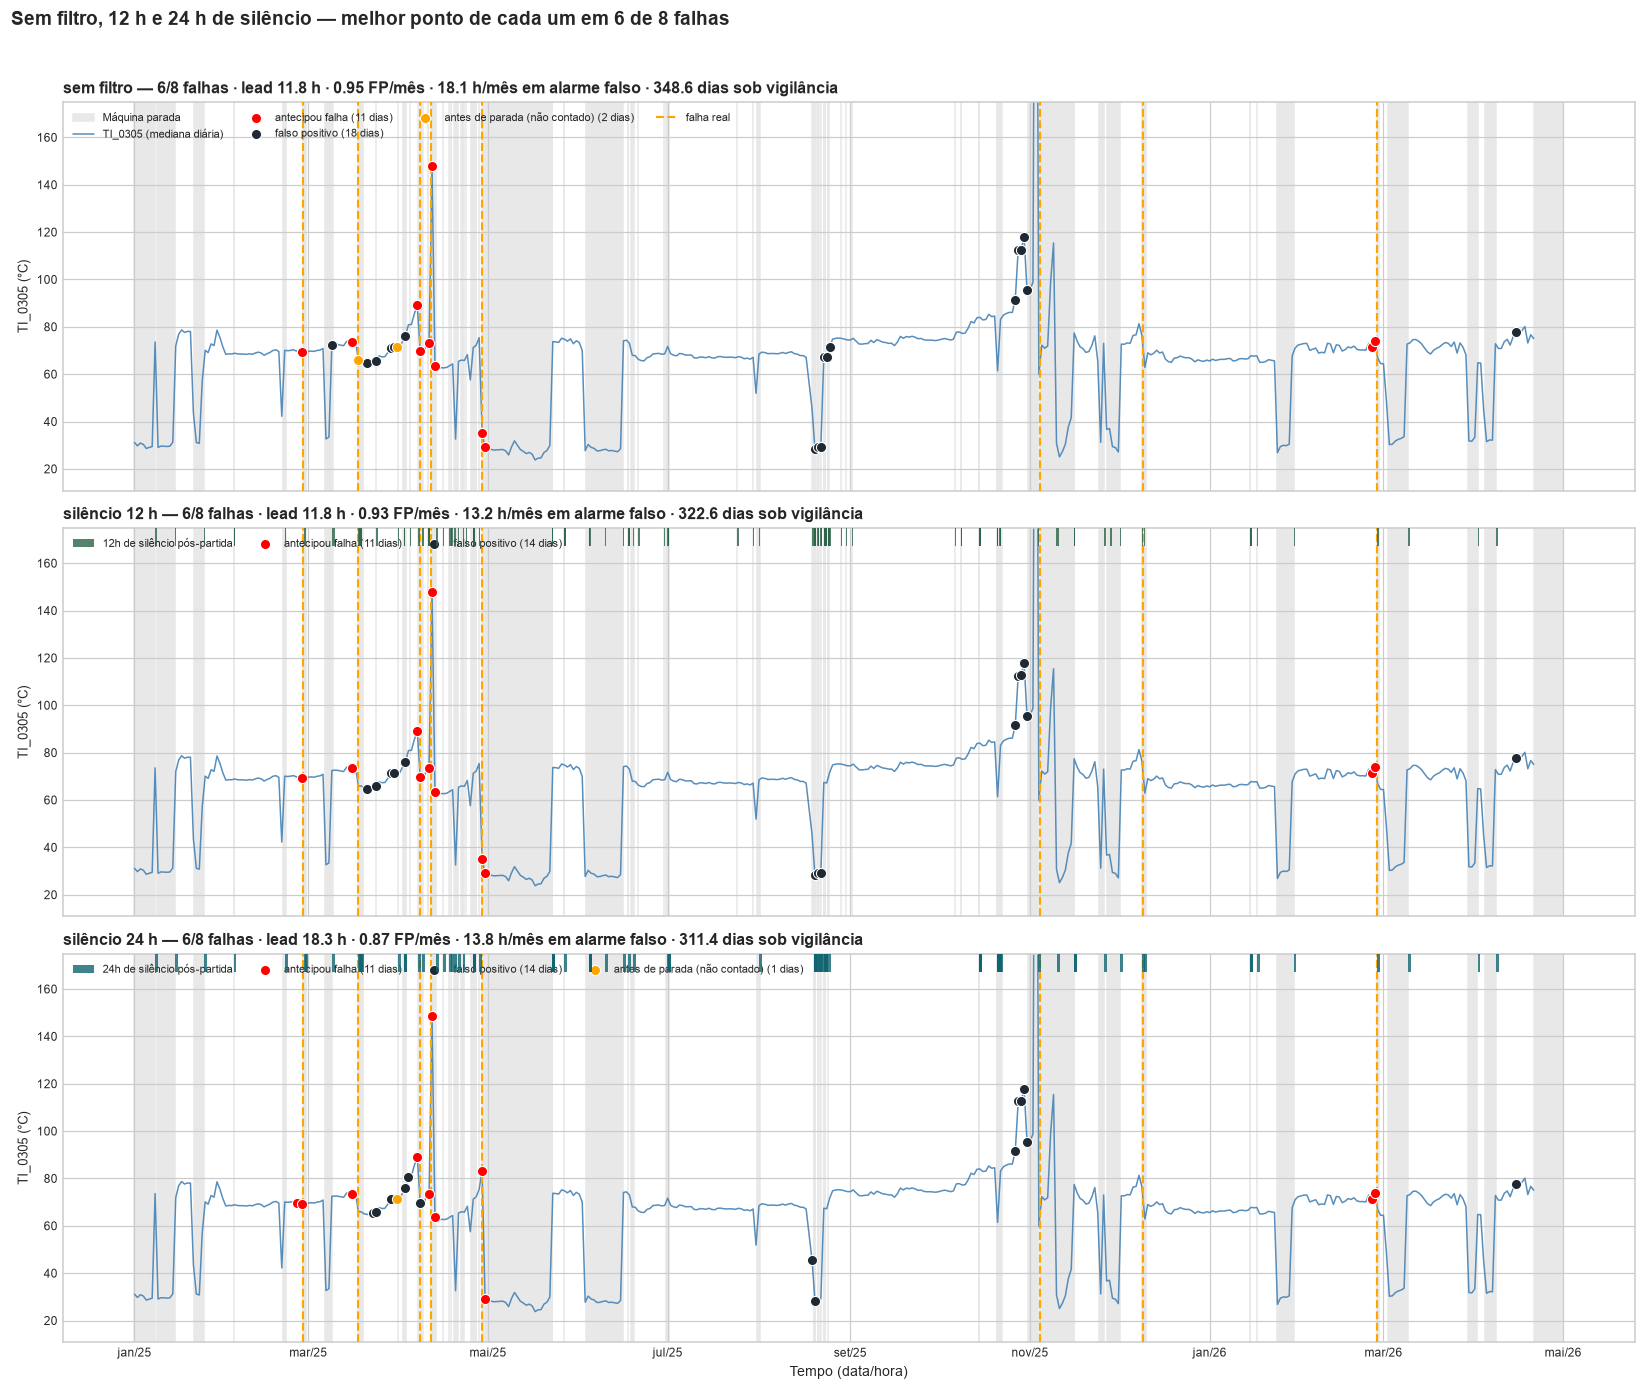

In [16]:

COMPARA_SILENCIO = [
    ("sem filtro", "0h",
     dict(model="pca", grid="30s", ewma="1h", threshold=99.9, sustain="2h",
          confirm=2, min_alert="0min", exclude_days=0, exclude_alarm_h=1.0)),
    ("silêncio 12 h", "12h",
     dict(model="pca", grid="30s", ewma="1h", threshold=99.9, sustain="2h",
          confirm=2, min_alert="0min", exclude_days=0, exclude_alarm_h=1.0)),
    ("silêncio 24 h", "24h",
     dict(model="pca", grid="2min", ewma="2h", threshold=99.9, sustain="30min",
          confirm=2, min_alert="0min", exclude_days=0, exclude_alarm_h=1.0)),
]
comp = {}
for nome, silencio, cfg in COMPARA_SILENCIO:
    automl.EXHAUST_GATE, automl.STARTUP_EXCLUDE, automl.POST_START_SILENCE = "off", "2h", silencio
    bundle = CachedBundle().build(); bundle._grids.clear(); bundle._trips = None
    cache = CACHES / f"placar_{silencio}"; cache.mkdir(exist_ok=True)
    comp[(nome, silencio)] = DetectionReplay(bundle=bundle, cache_dir=cache).run(
        baseline=POLITICA, **cfg)
automl.POST_START_SILENCE = "0h"

fig, axes = plt.subplots(3, 1, figsize=(15, 12.6), sharex=True)
for eixo, ((nome, silencio), r) in zip(axes, comp.items()):
    m = r.metrics
    s = viz.decimar(r.sensors[SENSOR], FREQ, "median")
    viz.sombrear_paradas(eixo, r.operability, FREQ, rotulo=(eixo is axes[0]))
    if silencio != "0h":
        operando = r.operability["in_operation"].astype(bool)
        partidas = operando & ~operando.shift(fill_value=False)
        primeiro = True
        for t0 in partidas[partidas].index:
            eixo.axvspan(t0, t0 + pd.Timedelta(silencio), ymin=0.955, ymax=1.0, lw=0,
                         color="#2c6349" if silencio == "12h" else "#0f6470",
                         alpha=0.8, zorder=8,
                         label=f"{silencio} de silêncio pós-partida" if primeiro else None)
            primeiro = False
    eixo.plot(s.index, s.to_numpy(), color=viz.COR_SERIE, lw=1.0, alpha=0.9,
              label="TI_0305 (mediana diária)" if eixo is axes[0] else None)
    for tipo, quando in viz.pontos_por_tipo(r, FREQ).items():
        v = s.reindex(quando).dropna()
        if v.empty:
            continue
        eixo.scatter(v.index, v.to_numpy(), s=44, zorder=6, color=viz.CORES_EPISODIO[tipo],
                     edgecolor="white", linewidth=0.7, label=f"{ROTULO[tipo]} ({len(v)} dias)")
    viz.marcar_eventos(eixo, r.events, rotulo="falha real" if eixo is axes[0] else None)
    eixo.set_ylim(baixo - margem, alto + margem)
    eixo.set_ylabel("TI_0305 (°C)", fontsize=8.5)
    eixo.set_title(f"{nome} — {m['eventos_detectados']}/8 falhas · lead {m['lead_medio_h']} h · "
                   f"{m['fp_por_mes']} FP/mês · {m['fp_horas_por_mes']} h/mês em alarme falso · "
                   f"{m['dias_avaliados']} dias sob vigilância",
                   loc="left", fontsize=10.5, fontweight="bold", pad=6)
    eixo.legend(loc="upper left", fontsize=7, ncol=4, framealpha=0.93)
axes[-1].set_xlabel("Tempo (data/hora)")
viz._formatar_eixo_x(axes[-1], s.index)
fig.suptitle("Sem filtro, 12 h e 24 h de silêncio — melhor ponto de cada um em 6 de 8 falhas",
             fontsize=12.5, fontweight="bold", x=0.006, ha="left", y=0.999)
fig.tight_layout(rect=[0, 0, 1, 0.985])
destino = RAIZ / "reports/figures/deteccao/silencio_12h_24h_serie.png"
fig.savefig(destino, dpi=150, bbox_inches="tight"); print("figura:", destino)
plt.show()


## 11. A régua importa tanto quanto o modelo

Um episódio de alerta é classificado como falso positivo se não anteceder falha nem for
seguido de parada real. A pergunta é **a partir de quando** se conta as 48 h do "seguido
de parada".

Hoje a janela é `[início do episódio, início + 48 h]`. Para episódios longos, isso é
claramente errado: temos episódios de 100 h em que a janela termina *dentro* do próprio
alerta, então uma parada que aconteça no meio dele não conta.

Três ancoragens possíveis:

| regra | janela de perdão |
|---|---|
| A (atual) | `[início, início + 48 h]` |
| B | `[fim, fim + 48 h]` |
| C | `[início, fim + 48 h]` — durante o alerta ou até 48 h depois dele |

A regra C é a defensável: a parada valeu se aconteceu **enquanto o alerta estava de pé ou
logo depois**. A célula abaixo recalcula os candidatos nas duas réguas.

In [17]:

JAN_PERDAO = pd.Timedelta(automl.DETECTION_WINDOW)

def avaliar_regra_c(r):
    """FP e horas em alarme falso com a janela de perdão [início, fim + 48 h]."""
    spans = dict(r.episode_spans)
    casados = {p for e in r.events for p in e.get("episodios", [])}
    dias = r.metrics["dias_avaliados"]          # já desconta silêncio e parada
    fp, horas = 0, 0.0
    for p in r.episodes:
        if p in casados:
            continue
        fim = max(spans.get(p, p), p)
        perdoado = (any(p <= pd.Timestamp(e["inicio"]) <= fim + JAN_PERDAO for e in r.events)
                    or any(p <= s <= fim + JAN_PERDAO for s in r.stops))
        if not perdoado:
            fp += 1
            horas += (fim - p).total_seconds() / 3600
    return round(fp / dias * 30, 2), round(horas / dias * 30, 1)

CANDIDATOS = [
    ("produção (2 min)",     "0h", dict(model="pca", grid="2min", ewma="2h",    threshold=99.9,   sustain="30min", confirm=2, min_alert="0min")),
    ("PCA 30 s, sem filtro", "0h", dict(model="pca", grid="30s",  ewma="1h",    threshold=99.9,   sustain="2h",    confirm=2, min_alert="0min")),
    ("PCA 30 s, alvo 5/8",   "0h", dict(model="pca", grid="30s",  ewma="30min", threshold=99.995, sustain="1h",    confirm=2, min_alert="30min")),
    ("silêncio 12 h",       "12h", dict(model="pca", grid="30s",  ewma="1h",    threshold=99.9,   sustain="2h",    confirm=2, min_alert="0min")),
    ("silêncio 24 h",       "24h", dict(model="pca", grid="2min", ewma="2h",    threshold=99.9,   sustain="30min", confirm=2, min_alert="0min")),
    ("silêncio 24 h, 5/8",  "24h", dict(model="pca", grid="2min", ewma="30min", threshold=99.97,  sustain="2h",    confirm=2, min_alert="0min")),
    ("ponto da Lara",        "0h", dict(model="pca", grid="2min", ewma="1h",    threshold=99.995, sustain="1h",    confirm=2, min_alert="30min")),
]
linhas, rodadas_cand = [], {}
for nome, silencio, cfg in CANDIDATOS:
    automl.EXHAUST_GATE, automl.STARTUP_EXCLUDE, automl.POST_START_SILENCE = "off", "2h", silencio
    bundle = CachedBundle().build(); bundle._grids.clear(); bundle._trips = None
    cache = CACHES / f"placar_{silencio}"; cache.mkdir(exist_ok=True)
    r = DetectionReplay(bundle=bundle, cache_dir=cache).run(baseline=POLITICA,
                                                            exclude_days=0, exclude_alarm_h=1.0, **cfg)
    rodadas_cand[nome] = r
    m = r.metrics
    fp_c, h_c = avaliar_regra_c(r)
    linhas.append(dict(candidato=nome, silencio=silencio, eventos=f"{m['eventos_detectados']}/8",
                       lead_h=m["lead_medio_h"], fp_A=m["fp_por_mes"], h_A=m["fp_horas_por_mes"],
                       fp_C=fp_c, h_C=h_c, dias=m["dias_avaliados"]))
automl.POST_START_SILENCE = "0h"
TABELA = pd.DataFrame(linhas).set_index("candidato")
TABELA


[dados] cache replay_raw_68b25f9d.parquet: 1,396,800 amostras | 2025-01-01 00:00:00 → 2026-04-30 23:59:30


[alarmes] 132 episódios de alarme em operação (76 só de utilidade/gás) servirão de avaliação secundária


[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_2min_3000h_0_1.0_1d30ff1f.pkl


...

[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_2min_3000h_0_1.0_1d30ff1f.pkl


[replay] pca|2min|b3000h|excl0d|alm1.0h|ewma1h|q99.995|sust1h|conf2|min30min -> 5/8 eventos | lead 8.8 h | FP 0.43/mês


,silencio,eventos,lead_h,fp_A,h_A,fp_C,h_C,dias
candidato,,,,,,,,
produção (2 min),0h,6/8,18.3,0.94,22.0,0.86,13.3,350.5
"PCA 30 s, sem filtro",0h,6/8,11.8,0.95,18.1,0.86,9.2,348.6
"PCA 30 s, alvo 5/8",0h,5/8,9.0,0.52,8.7,0.52,8.7,348.6
silêncio 12 h,12h,6/8,11.8,0.93,13.2,0.84,3.6,322.6
silêncio 24 h,24h,6/8,18.3,0.87,13.8,0.77,4.0,311.4
"silêncio 24 h, 5/8",24h,5/8,8.5,0.58,2.0,0.58,2.0,311.4
ponto da Lara,0h,5/8,8.8,0.43,10.2,0.43,10.2,350.5


**Leitura.** A regra C tira entre 0,08 e 0,10 do FP/mês de todo mundo, mas o efeito grande
é nas **horas**: a produção cai de 22,0 para 13,3 e o PCA de 30 s cai de 18,1 para
**9,2 h/mês**. Faz sentido: quem se beneficia são os episódios longos, que são poucos em
número e dominam as horas.

Os pontos de 5/8 não mudam, porque os episódios deles já são curtos.

## 12. O melhor resultado

Critério da equipe, na ordem: **respeitar o teto de 1 FP/mês**, depois **alarmar o mínimo
de horas**, depois **antecipar mais falhas**. Aplicado à tabela acima, com a regra C:

In [18]:

final = TABELA.copy()
final["passa_no_teto"] = final.fp_C <= TETO_FP
ranking = final[final.passa_no_teto].sort_values(["h_C", "eventos"], ascending=[True, False])
display(ranking[["eventos", "lead_h", "fp_C", "h_C", "dias", "silencio"]])

campeao = ranking.index[0]
print(f"\nMELHOR RESULTADO: {campeao}")
l = ranking.loc[campeao]
print(f"  falhas antecipadas ........ {l.eventos}")
print(f"  antecedência média ........ {l.lead_h} h")
print(f"  falso positivo ............ {l.fp_C}/mês")
print(f"  tempo em alarme falso ..... {l.h_C} h/mês")
print(f"  dias sob vigilância ....... {l.dias}")


,eventos,lead_h,fp_C,h_C,dias,silencio
candidato,,,,,,
"silêncio 24 h, 5/8",5/8,8.5,0.58,2.0,311.4,24h
silêncio 12 h,6/8,11.8,0.84,3.6,322.6,12h
silêncio 24 h,6/8,18.3,0.77,4.0,311.4,24h
"PCA 30 s, alvo 5/8",5/8,9.0,0.52,8.7,348.6,0h
"PCA 30 s, sem filtro",6/8,11.8,0.86,9.2,348.6,0h
ponto da Lara,5/8,8.8,0.43,10.2,350.5,0h
produção (2 min),6/8,18.3,0.86,13.3,350.5,0h



MELHOR RESULTADO: silêncio 24 h, 5/8
  falhas antecipadas ........ 5/8
  antecedência média ........ 8.5 h
  falso positivo ............ 0.58/mês
  tempo em alarme falso ..... 2.0 h/mês
  dias sob vigilância ....... 311.4


### Recomendação

**Se o silêncio pós-partida for aceito pela operação:** o de **12 h** é o melhor resultado
do trabalho. Entrega 6 de 8 falhas com **3,6 h/mês** em alarme falso e 0,84 FP/mês,
cegando 7,5% do tempo de operação. Contra o de 24 h, ele tem 6 configurações viáveis em
vez de 1, o que é o que sustenta o resultado se o equipamento mudar de regime.

**Se o silêncio for recusado** — e a objeção é legítima, porque a janela cega cai
justamente quando a máquina volta de reparo — o melhor é **PCA na grade de 30 s, sem
filtro nenhum**: 6 de 8 falhas, 0,86 FP/mês e **9,2 h/mês**, com vigilância integral dos
348,6 dias. É praticamente o mesmo falso positivo da configuração que roda hoje, com
**metade do tempo em alarme**, e a única mudança é a resolução do dado e o ponto de
operação. Nenhuma regra discutível envolvida.

**O que eu apresentaria como oficial:** o PCA de 30 s sem filtro. O silêncio de 12 h entra
como melhoria opcional, com o custo declarado, para a operação decidir.

### O que continua fora do alcance

As falhas de **04/11/2025** e **09/12/2025** não são antecipadas por nenhuma das 51.840
configurações avaliadas nas cinco varreduras dentro do teto de falso positivo. A primeira
por observabilidade (o compressor operou 13,3 h das 48 h da janela) e a segunda por
ausência de precursor em qualquer um dos 36 sensores. Esse teto é dos dados, não do
modelo, e a saída passa por mais dado: 2024 completo, catálogo validado com a manutenção e
vibração com resolução espectral.